## PAPER WALKTHROUGH 

In [1]:
import numpy as np
import matplotlib.pyplot as plt


import sys
import os

sys.path.append(os.path.abspath("../src"))

In [2]:
from batchnorm import BatchNorm
from neural_network import NeuralNetwork

In [3]:
x = np.random.normal(loc=100,scale=25,size=(32,10))

print(f"This is the shape of our input data: {x.shape}")



This is the shape of our input data: (32, 10)


In [4]:
batch = BatchNorm()
scaled_x = batch.forward(x)

print(f"this is the shape of scaled_x: {scaled_x.shape}")

print(f"This is the scaled_x: {scaled_x}")

this is the shape of scaled_x: (32, 10)
This is the scaled_x: [[-1.45679817e+00  4.25985534e-01  1.40461922e-01  4.74657095e-01
  -1.38888404e+00  8.71015598e-01 -3.50530081e-01 -3.95360363e-02
   1.71129129e+00  8.15010676e-01]
 [-5.35424781e-01 -4.43220202e-01 -8.78564391e-01  4.27112852e-01
   7.03932390e-01 -9.30137479e-01 -1.42387207e+00 -1.08292211e-01
  -5.78572908e-01  9.81516886e-01]
 [-6.55927237e-01  1.08323450e+00 -2.82239781e-01  1.99631236e+00
   1.57056234e-01 -4.25231676e-01  4.88736734e-01 -8.88921452e-01
   6.18500040e-01 -4.01023465e-01]
 [ 8.91495956e-01 -1.55393080e+00  2.45448193e+00 -7.23392730e-01
   1.40322254e-01  5.02443182e-01  1.06107904e+00  1.55135601e+00
   1.20255663e-03 -5.82613129e-01]
 [ 1.49700577e+00  2.29748220e-01  2.37248460e-01  1.52960761e-01
   8.21373121e-01  4.67029379e-01 -8.25038271e-02  5.46533072e-01
   2.08270305e+00 -4.61369156e-01]
 [-6.31236421e-01  1.21456343e-02 -3.13503467e-01  1.06546720e+00
  -1.19117574e+00 -2.36532467e-02 -1.

In [5]:
print(f"The mean is this: {np.mean(scaled_x)}")
print(f"The variance is this: {np.var(scaled_x)}")


The mean is this: -1.4988010832439614e-16
The variance is this: 0.9999999816190931


### Neural Network Forward Pass

In [6]:
network = NeuralNetwork(10,5)

batch = BatchNorm()

network.forward(x,batch)

this is the shape of Z1: (32, 5)
this is the shape of Z2: (32, 5)


array([[0.        , 0.        , 0.        , 1.61004587, 0.95986882],
       [0.50703224, 0.26272636, 0.38490921, 0.57450912, 0.        ],
       [0.        , 0.        , 0.        , 0.52450103, 1.27766989],
       [1.26377662, 0.81451218, 0.        , 0.        , 0.64872178],
       [0.        , 0.18943069, 0.6889263 , 0.94270686, 1.14498899],
       [0.97666882, 0.15340405, 0.        , 0.45494992, 0.        ],
       [0.07020948, 0.89083845, 0.        , 0.        , 0.17165432],
       [0.        , 0.        , 1.05506729, 2.23356972, 0.        ],
       [1.45129293, 0.        , 0.        , 0.        , 1.0548475 ],
       [0.29592319, 0.        , 0.        , 0.02749098, 2.17115574],
       [0.        , 0.        , 1.86419077, 0.        , 0.55613083],
       [1.77253336, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 1.1625518 , 0.69154794, 0.        , 0.        ],
       [0.        , 1.28161169, 1.79773299, 1.12364084, 0.        ],
       [0.        , 0.        , 0.

### Visualization

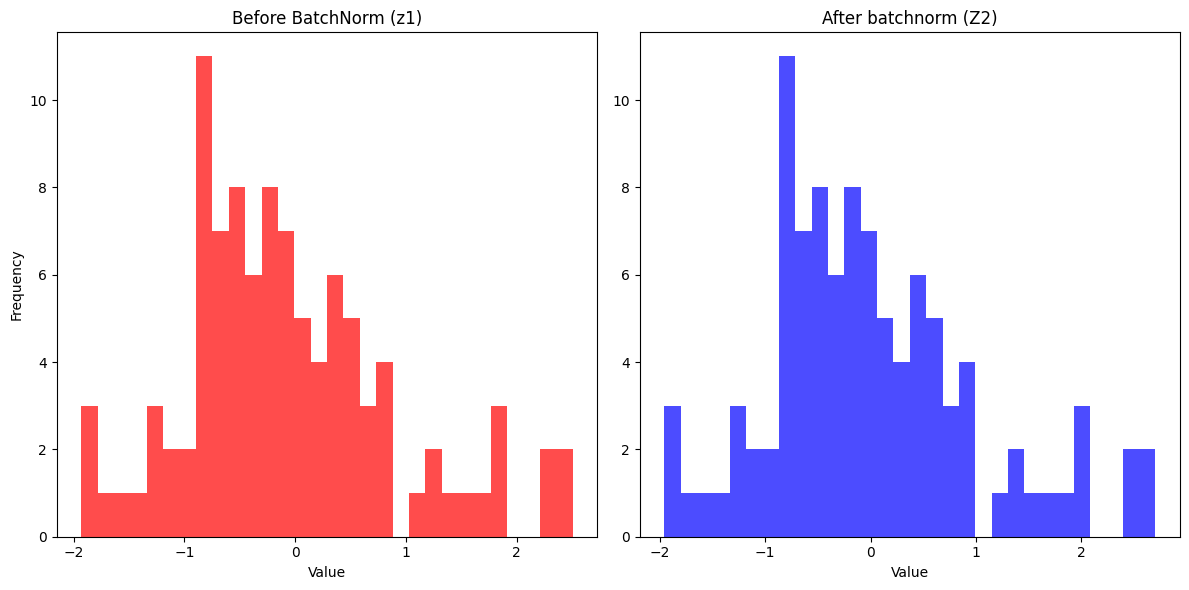

In [7]:
x_messy = np.random.normal(loc=0,scale=1,size=(100,1))

bn = BatchNorm()


x_normalized = bn.forward(x_messy)

plt.figure(figsize=(12,6))


plt.subplot(1,2,1)
plt.hist(x_messy,bins=30,color="red",alpha=0.7)

plt.title("Before BatchNorm (z1)")

plt.xlabel("Value")
plt.ylabel("Frequency")



plt.subplot(1,2,2)
plt.hist(x_normalized,bins=30,color="blue",alpha=0.7)
plt.title("After batchnorm (Z2)")
plt.xlabel("Value")


plt.tight_layout()
plt.show()

## BACKPROPAGATION

In [8]:
bn = BatchNorm()

y = bn.forward(x)

print(f"Beta shape after fresh start: {bn.beta.shape}")

dout = np.random.randn(*y.shape)

Beta shape after fresh start: (1, 10)


### Numerical Error

In [9]:





epsilon = 1e-5
grad_num_x = np.zeros_like(x)

grad_num_beta = np.zeros_like(bn.beta)
grad_num_gamma = np.zeros_like(bn.gamma)


print(f"Shape of x: {x.shape}")
print(f"shape of beta is: {bn.beta.shape}")
print(f"shape of gamma is: {bn.gamma.shape}")


for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        
        original_val = x[i,j]
        
        #print(original_val)
        #print(f"what is in i: {x[i]}\n what is in j : {x[j]}")
        
        x[i,j] = original_val + epsilon
        
        y_pos = bn.forward(x)
        
        l_pos = np.sum(y_pos*dout)
        
        x[i,j] = original_val - epsilon
        
        y_neg = bn.forward(x)
        l_neg = np.sum(y_neg * dout)
        
        x[i,j] = original_val
        
        grad_num_x[i,j] =(l_pos - l_neg)/ (2 * epsilon)
        
        
        
for j in range(bn.beta.shape[1]):
          #########BETA###############
        original_beta = bn.beta[0,j]
        
        
        bn.beta[0,j] = original_beta + epsilon
        y_b_pos = bn.forward(x)
        
        l_b_pos = np.sum(y_b_pos * dout)
        
        bn.beta[0,j] = original_beta - epsilon
        y_b_neg = bn.forward(x)
        
        l_b_neg = np.sum(y_b_neg * dout)
        
        bn.beta[0, j] = original_beta
    
        # Calculate gradient
        grad_num_beta[0, j] = (l_b_pos - l_b_neg) / (2 * epsilon)
        
        
        
for j in range(bn.gamma.shape[1]):
          #########BETA###############
        original_gamma = bn.gamma[0,j]
        
        
        bn.gamma[0,j] = original_gamma + epsilon
        y_b_pos = bn.forward(x)
        
        l_b_pos = np.sum(y_b_pos * dout)
        
        bn.gamma[0,j] = original_gamma - epsilon
        y_b_neg = bn.forward(x)
        
        l_b_neg = np.sum(y_b_neg * dout)
        
        bn.gamma[0, j] = original_gamma
    
        # Calculate gradient
        grad_num_gamma[0, j] = (l_b_pos - l_b_neg) / (2 * epsilon)
        
        
        
        
print(f"Shape of grad_num_x: {grad_num_x.shape}")
print(f"Shape of grad_num_beta: {grad_num_beta.shape}")

print(f"Shape of grad_num_gamma: {grad_num_gamma.shape}")
        
        
    

Shape of x: (32, 10)
shape of beta is: (1, 10)
shape of gamma is: (1, 10)
Shape of grad_num_x: (32, 10)
Shape of grad_num_beta: (1, 10)
Shape of grad_num_gamma: (1, 10)


## Analytical Error

In [10]:




dx_analytical,d_beta_analytical,d_gamma_analytical = bn.backward(dout)

print(f"Analytical dx shape: {dx_analytical.shape}")
print(f"Beta dx shape: {d_beta_analytical.shape}")
print("First few values of analytical dx:")
print(dx_analytical[0,:5])

The shape of d_normalized: (32, 10)
The shape of batch_mean : (1, 10)
The shape of d_var : (10,)
The shape of d_mean :(10,)
Analytical dx shape: (32, 10)
Beta dx shape: (1, 10)
First few values of analytical dx:
[ 0.0249151   0.00097313 -0.10689418 -0.12127543 -0.02670493]


In [11]:
# Assuming your loop for grad_num_x is finished
rel_error = np.max(np.abs(dx_analytical - grad_num_x) / np.maximum(1e-8, np.abs(dx_analytical) + np.abs(grad_num_x)))

print(f"Maximum Relative Error: {rel_error}")

Maximum Relative Error: 2.4340090364518194e-07


In [12]:
print("Analytical d_beta:", d_beta_analytical[0, :5])
print("Numerical d_beta:", grad_num_beta[0, :5])

Analytical d_beta: [-1.00346283 -4.95745513  3.59191586 -4.40629267  3.25666542]
Numerical d_beta: [-1.00346283 -4.95745513  3.59191586 -4.40629267  3.25666542]


In [13]:
# Assuming your loop for grad_num_x is finished
rel_error = np.max(np.abs(d_beta_analytical - grad_num_beta) / np.maximum(1e-8, np.abs(d_beta_analytical) + np.abs(grad_num_beta)))

print(f"Maximum Relative Error: {rel_error}")

Maximum Relative Error: 6.03493543440056e-10


In [14]:
# Assuming your loop for grad_num_x is finished
rel_error = np.max(np.abs(d_gamma_analytical - grad_num_gamma) / np.maximum(1e-8, np.abs(d_gamma_analytical) + np.abs(grad_num_gamma)))

print(f"Maximum Relative Error: {rel_error}")

Maximum Relative Error: 4.491267116413243e-11
